In [ ]:
### Importation des librairies ###


import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import rasterio
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from pathlib import Path
from fonction import *
import seaborn as sns
import gc
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import time

In [4]:
### Importation de la base ###


# Importation
gdf = gpd.read_file('data/processed/jointure_meteo_swi_argile_nearest.gpkg')

# Affichage
display(gdf)

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,WG_RACINE,WGI_RACINE,TINF_H,TSUP_H,YEAR,ALEA,NIVEAU,DPT,dist_to_argile,geometry
0,3827,773980,6713410,1960-12-01,0.982,5.7,59.2,1.941935,3.132258,4.049000,...,0.370645,0.003516,-5.7,12.0,1960,Moyen,2.0,89,0.000000,POINT (723999.802 2280998.23)
1,3826,765986,6713478,1960-12-01,0.977,4.8,58.9,2.216129,3.254839,4.104935,...,0.351065,0.002323,-5.4,12.3,1960,Moyen,2.0,89,0.000000,POINT (715999.436 2280998.385)
2,3825,757993,6713546,1960-12-01,0.973,4.4,58.9,2.338710,3.300000,4.130161,...,0.334355,0.001806,-5.2,12.4,1960,Moyen,2.0,89,0.000000,POINT (708000.072 2280998.598)
3,3824,749999,6713614,1960-12-01,0.973,4.4,58.9,2.338710,3.300000,4.130161,...,0.324452,0.001806,-5.2,12.4,1960,Faible,1.0,89,0.000000,POINT (699999.708 2280998.852)
4,5323,717146,6609971,1960-09-01,0.449,0.0,73.6,13.356667,1.530000,8.058967,...,0.263533,0.000000,2.3,24.0,1960,Moyen,2.0,3,0.000000,POINT (667998.94 2176998.552)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7005175,7245,363949,6429068,2024-08-01,0.124,0.0,37.5,20.451613,1.880645,11.601839,...,0.144290,0.000000,9.6,37.0,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292)
7005176,7245,363949,6429068,2024-03-01,1.042,0.0,160.8,10.851613,2.603226,6.793806,...,0.222710,0.000000,2.0,22.7,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292)
7005177,7245,363949,6429068,2024-12-01,0.695,0.0,72.5,8.048387,2.909677,5.864935,...,0.206065,0.000000,0.8,16.1,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292)
7005178,7245,363949,6429068,2024-05-01,0.770,0.0,94.9,15.264516,2.796774,8.711000,...,0.191290,0.000000,9.2,27.6,2024,Aucun,0.0,33,24729.333576,POINT (315997.597 1992998.292)


In [6]:
### Affichage de la liste des variables ###


list(gdf.columns)

['NUMERO',
 'LAMBX',
 'LAMBY',
 'DATE',
 'SWI_UNIF_MENS',
 'PRENEI',
 'PRELIQ',
 'T',
 'FF',
 'Q',
 'DLI',
 'SSI',
 'HU',
 'EVAP',
 'ETP',
 'PE',
 'SWI',
 'SSWI_10J',
 'DRAINC',
 'RUNC',
 'RESR_NEIGE',
 'RESR_NEIGE6',
 'HTEURNEIGE',
 'HTEURNEIGE6',
 'HTEURNEIGEX',
 'SNOW_FRAC',
 'ECOULEMENT',
 'WG_RACINE',
 'WGI_RACINE',
 'TINF_H',
 'TSUP_H',
 'YEAR',
 'ALEA',
 'NIVEAU',
 'DPT',
 'dist_to_argile',
 'geometry']

In [7]:
### Optimisation de la mémoire : conversion des float64 en float32 ###


# Sélection des colonnes de type float64
cols_float = gdf.select_dtypes(include=['float64']).columns

# Conversion en float32
gdf[cols_float] = gdf[cols_float].astype('float32')

gc.collect()

0

In [8]:
### Isolement de la variable de SWI uniforme mensuel (y) et des variables météorologiques ###


# Variable de SWI uniforme mensuel
y = gdf["SWI_UNIF_MENS"]

# Variables météorologiques
meteo_vars = [
    "T", "Q", "FF",
    "PRENEI", "PRELIQ",
    "SSI", "DLI", "ETP", "PE",
    "RESR_NEIGE", "RESR_NEIGE6",
    "HTEURNEIGE", "HTEURNEIGE6", "HTEURNEIGEX",
    "SNOW_FRAC", "ECOULEMENT",
    "TINF_H", "TSUP_H",
    "NIVEAU", "dist_to_argile"
]

## 2. VAE Conditionnel Spatial — Option B

Chaque timestep = une **carte SWI de la France** (grille SAFRAN 8 km).  
Le CVAE génère des cartes réalistes **conditionnées sur le mois** via encodage sin/cos.

```
Encodeur : (B,1,H,W) → Conv×3 (stride 2) → FC → μ, log_σ²
Décodeur : (z, cond) → FC → ConvTranspose×3 → (B,1,H,W)
```

### 2.1  Imports

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import TSNE
import warnings; warnings.filterwarnings('ignore')

try:
    import umap; HAS_UMAP = True; print('umap-learn OK')
except ImportError:
    HAS_UMAP = False; print('umap absent → t-SNE utilisé')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

umap absent → t-SNE utilisé
Device : cpu


### 2.2  Construction de la grille spatiale

In [10]:
# Les coordonnees LAMBX/LAMBY varient legerement d'un point a l'autre.
# On arrondit au pas SAFRAN (8000 m) pour obtenir une vraie grille 2D reguliere.
STEP = 8000

lambx_g = (gdf['LAMBX'] / STEP).round().astype(int) * STEP
lamby_g = (gdf['LAMBY'] / STEP).round().astype(int) * STEP

unique_x = np.sort(lambx_g.unique()).astype(np.int64)   # axe E-O
unique_y = np.sort(lamby_g.unique()).astype(np.int64)   # axe S-N

x_to_col = {int(v): i for i, v in enumerate(unique_x)}
y_to_row  = {int(v): i for i, v in enumerate(unique_y)}

H, W = len(unique_y), len(unique_x)
print(f'Grille : {H} x {W} = {H*W:,} cellules')
print(f'Points actifs France : {gdf["NUMERO"].nunique():,}')
print(f'Taille tenseur estimee : {T * H * W * 4 / 1e6:.1f} MB')

Grille : 133 x 132 = 17,556 cellules
Points actifs France : 8,981
Taille tenseur estimee : 54.8 MB


### 2.3  Tenseur des cartes SWI  `(T, H, W)`

In [11]:
import gc

dates_all   = np.sort(gdf['DATE'].unique())
T           = len(dates_all)
date_to_idx = {d: i for i, d in enumerate(dates_all)}
months_arr  = pd.DatetimeIndex(dates_all).month.values.astype(np.int32)
years_arr   = pd.DatetimeIndex(dates_all).year.values.astype(np.int32)

print(f'T = {T} pas de temps  ({dates_all[0]} → {dates_all[-1]})')

T = 780 pas de temps  (1960-01-01T00:00:00.000 → 2024-12-01T00:00:00.000)


In [12]:
# Remplissage vectorise avec les coordonnees arrondies
col_idx  = lambx_g.map(x_to_col).values.astype(np.int32)
row_idx  = lamby_g.map(y_to_row).values.astype(np.int32)
t_idx    = gdf['DATE'].map(date_to_idx).values.astype(np.int32)
swi_vals = gdf['SWI_UNIF_MENS'].values.astype(np.float32)

swi_maps = np.full((T, H, W), np.nan, dtype=np.float32)
swi_maps[t_idx, row_idx, col_idx] = swi_vals
gc.collect()

print(f'swi_maps : {swi_maps.shape}  ({swi_maps.nbytes/1e6:.1f} MB)')
print(f'SWI : min={np.nanmin(swi_maps):.3f}  max={np.nanmax(swi_maps):.3f}')

swi_maps : (780, 133, 132)  (54.8 MB)
SWI : min=-0.057  max=1.542


### 2.4  Preprocessing

**Standardisation mensuelle** : `swi_norm = (swi − mean_m) / std_m`  
Le VAE apprend les **anomalies** par rapport au cycle saisonnier.  
**Padding** H,W → multiples de 8 pour les Conv stride=2.

In [13]:
# Masque France
land_mask = np.isfinite(swi_maps).any(axis=0)      # (H, W) bool
print(f'Pixels France : {land_mask.sum()} / {H*W}')

Pixels France : 8961 / 17556


In [14]:
# Stats mensuelles
monthly_stats = {}
for m in range(1, 13):
    vals = swi_maps[months_arr == m][:, land_mask]
    monthly_stats[m] = (float(np.nanmean(vals)), float(np.nanstd(vals)))

print('Mois  mean    std')
for m, (mu, s) in monthly_stats.items():
    print(f'  {m:2d}  {mu:.4f}  {s:.4f}')

Mois  mean    std
   1  0.8800  0.1897
   2  0.9223  0.1499
   3  0.9032  0.1346
   4  0.8303  0.1598
   5  0.7211  0.1935
   6  0.5449  0.2222
   7  0.3474  0.2122
   8  0.2347  0.2000
   9  0.2393  0.2159
  10  0.3805  0.2709
  11  0.5898  0.2865
  12  0.7713  0.2480


In [15]:
# Normalisation mensuelle
swi_norm = np.full_like(swi_maps, np.nan)
for m in range(1, 13):
    idx_m = months_arr == m
    mu_m, sig_m = monthly_stats[m]
    swi_norm[idx_m] = (swi_maps[idx_m] - mu_m) / (sig_m + 1e-8)

swi_norm_filled = np.nan_to_num(swi_norm, nan=0.0).astype(np.float32)

In [16]:
# Padding à multiple de 8
H_pad, W_pad = int(np.ceil(H/8))*8, int(np.ceil(W/8))*8
pad_h, pad_w = H_pad - H, W_pad - W

swi_padded  = np.pad(swi_norm_filled, ((0,0),(0,pad_h),(0,pad_w)), constant_values=0.0)
mask_padded = np.pad(land_mask.astype(np.float32), ((0,pad_h),(0,pad_w)), constant_values=0.0)
mask_tensor = torch.from_numpy(mask_padded)

print(f'Grille paddée : {H_pad}×{W_pad}  (depuis {H}×{W})')

Grille paddée : 136×136  (depuis 133×132)


### 2.5  Visualisation des cartes SWI (année de référence)

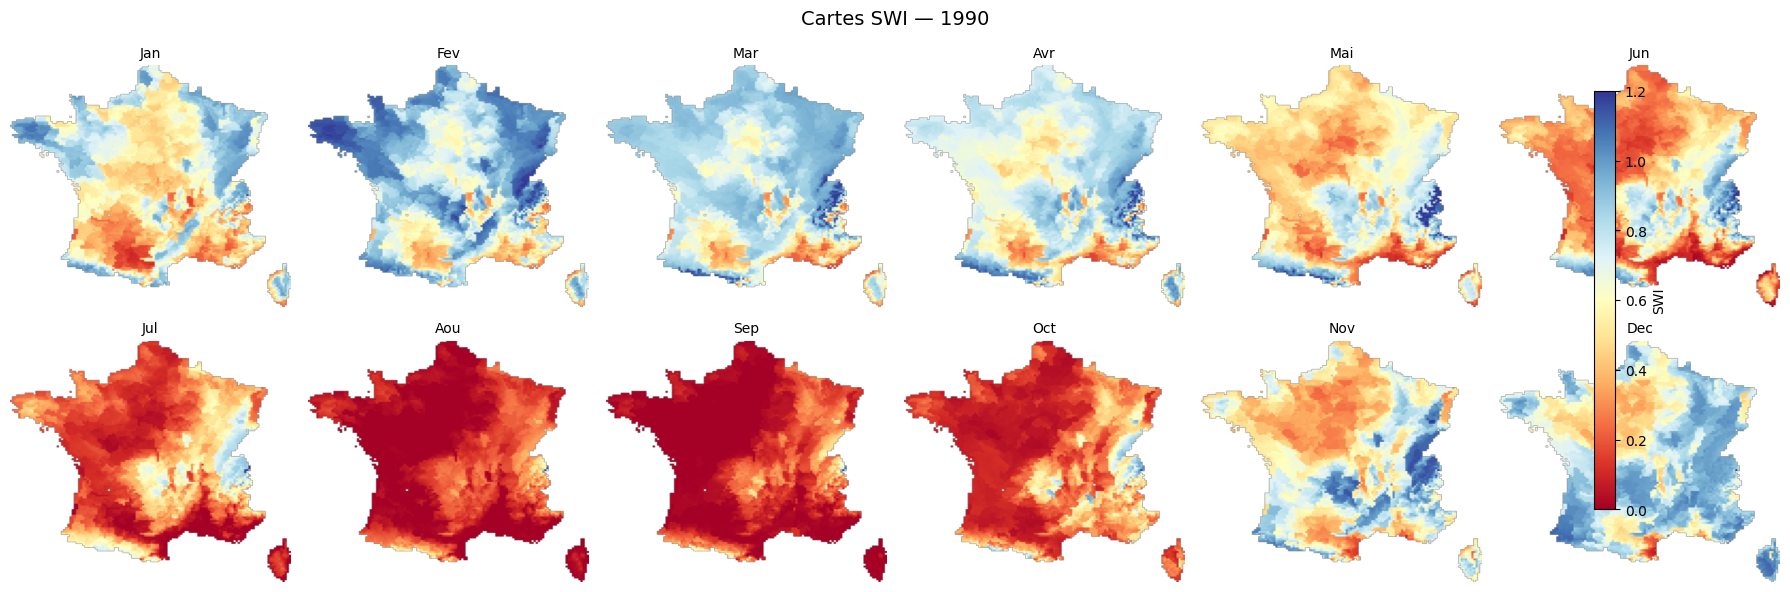

In [17]:
month_labels = ['Jan','Fev','Mar','Avr','Mai','Jun',
                'Jul','Aou','Sep','Oct','Nov','Dec']
year_ref = 1990

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle(f'Cartes SWI — {year_ref}', fontsize=14)

for m in range(1, 13):
    ax = axes[(m-1)//6, (m-1)%6]
    idx = np.where((months_arr == m) & (years_arr == year_ref))[0]
    if not len(idx): ax.axis('off'); continue
    carte = swi_maps[idx[0]].copy(); carte[~land_mask] = np.nan
    im = ax.imshow(carte, cmap='RdYlBu', origin='lower', vmin=0, vmax=1.2, aspect='auto')
    ax.set_title(month_labels[m-1], fontsize=10); ax.axis('off')

plt.colorbar(im, ax=axes, label='SWI', fraction=0.015, pad=0.04)
plt.tight_layout(); plt.show()

### 2.6  Dataset PyTorch

In [18]:
class SWIMapDataset(Dataset):
    """Cartes SWI (H_pad×W_pad) avec condition mensuelle [sin_m, cos_m]."""
    def __init__(self, maps, months):
        self.maps   = torch.from_numpy(maps[:, None, :, :])   # (T,1,H,W)
        theta       = 2 * np.pi * months / 12
        self.cond   = torch.from_numpy(
            np.stack([np.sin(theta), np.cos(theta)], axis=1).astype(np.float32))
        self.months = torch.from_numpy(months)

    def __len__(self): return len(self.maps)

    def __getitem__(self, i):
        return self.maps[i], self.cond[i], self.months[i]

In [19]:
BATCH_SIZE = 16
mask_train = years_arr < 2018
mask_test  = years_arr >= 2018

train_ds = SWIMapDataset(swi_padded[mask_train], months_arr[mask_train])
test_ds  = SWIMapDataset(swi_padded[mask_test],  months_arr[mask_test])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train : {len(train_ds)} cartes  |  Test : {len(test_ds)} cartes')

Train : 696 cartes  |  Test : 84 cartes


### 2.7  Architecture du CVAE

La condition `[sin_mois, cos_mois]` est concaténée **au bottleneck** encodeur  
et **à l'entrée** du décodeur — chaque mois a ainsi son propre sous-espace latent.

In [20]:
LATENT_DIM = 32
COND_DIM   = 2

class Encoder(nn.Module):
    def __init__(self, H_pad, W_pad, ldim=LATENT_DIM, cdim=COND_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1,   32, 3, 2, 1), nn.GroupNorm(8,  32), nn.LeakyReLU(0.2),
            nn.Conv2d(32,  64, 3, 2, 1), nn.GroupNorm(16, 64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 3, 2, 1), nn.GroupNorm(32,128), nn.LeakyReLU(0.2),
        )
        self.hb, self.wb = H_pad//8, W_pad//8
        flat = 128 * self.hb * self.wb
        self.fc    = nn.Sequential(nn.Linear(flat + cdim, 512), nn.LeakyReLU(0.2))
        self.mu    = nn.Linear(512, ldim)
        self.logv  = nn.Linear(512, ldim)

    def forward(self, x, cond):
        h = torch.cat([self.conv(x).flatten(1), cond], 1)
        h = self.fc(h)
        return self.mu(h), self.logv(h)

In [21]:
class Decoder(nn.Module):
    def __init__(self, H_pad, W_pad, ldim=LATENT_DIM, cdim=COND_DIM):
        super().__init__()
        self.hb, self.wb = H_pad//8, W_pad//8
        flat = 128 * self.hb * self.wb
        self.fc = nn.Sequential(
            nn.Linear(ldim + cdim, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, flat),        nn.LeakyReLU(0.2),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.GroupNorm(16, 64), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64,  32, 4, 2, 1), nn.GroupNorm(8,  32), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32,   1, 4, 2, 1),
        )

    def forward(self, z, cond):
        h = self.fc(torch.cat([z, cond], 1))
        return self.deconv(h.view(h.size(0), 128, self.hb, self.wb))

In [22]:
class CVAE(nn.Module):
    """Conditional VAE conditionné sur [sin_mois, cos_mois]."""
    def __init__(self, H_pad, W_pad):
        super().__init__()
        self.encoder = Encoder(H_pad, W_pad)
        self.decoder = Decoder(H_pad, W_pad)

    def reparameterize(self, mu, lv):
        if self.training:
            return mu + torch.exp(0.5 * lv) * torch.randn_like(mu)
        return mu

    def forward(self, x, cond):
        mu, lv = self.encoder(x, cond)
        return self.decoder(self.reparameterize(mu, lv), cond), mu, lv

In [23]:
model = CVAE(H_pad, W_pad).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'CVAE — paramètres : {n_params:,}')

# Test forward
xb, cb, _ = next(iter(train_loader))
xb, cb = xb.to(device), cb.to(device)
x_hat, mu, lv = model(xb, cb)
print(f'Input {tuple(xb.shape)} → Output {tuple(x_hat.shape)}')
print(f'Latent : μ {tuple(mu.shape)},  log_σ² {tuple(lv.shape)}')

CVAE — paramètres : 38,226,849
Input (16, 1, 136, 136) → Output (16, 1, 136, 136)
Latent : μ (16, 32),  log_σ² (16, 32)


### 2.8  Fonction de perte — ELBO masquée + β-annealing

- **Reconstruction** : MSE uniquement sur les pixels France (masque)  
- **KL** : β lineaire 0→1 sur `WARMUP_EPOCHS` pour éviter le *posterior collapse*

In [24]:
def elbo_loss(x, x_hat, mu, lv, mask, beta=1.0):
    m     = mask[None, None]                           # (1,1,H,W)
    recon = ((x - x_hat)**2 * m).sum() / (x.size(0) * mask.sum())
    kl    = -0.5 * (1 + lv - mu.pow(2) - lv.exp()).sum(1).mean()
    return recon + beta * kl, recon.item(), kl.item()

In [25]:
def run_epoch(model, loader, mask, beta, opt=None):
    model.train(opt is not None)
    tot = rec = kld = 0.0
    ctx = torch.enable_grad() if opt else torch.no_grad()
    with ctx:
        for x, cond, _ in loader:
            x, cond = x.to(device), cond.to(device)
            x_hat, mu, lv = model(x, cond)
            loss, r, kl = elbo_loss(x, x_hat, mu, lv, mask, beta)
            if opt:
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
            tot += loss.item(); rec += r; kld += kl
    n = len(loader)
    return tot/n, rec/n, kld/n

### 2.9  Entraînement

In [ ]:
N_EPOCHS, LR, WARMUP = 80, 3e-4, 20
opt = torch.optim.Adam(model.parameters(), lr=LR)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS, eta_min=1e-5)
mask_dev = mask_tensor.to(device)
history  = {'tr':[], 'va':[], 'rec':[], 'kl':[]}

print(f'{'Ep':>4}  {'β':>5}  {'Train':>8}  {'Val':>8}  {'Rec':>8}  {'KL':>7}')
print('-'*50)
for ep in range(1, N_EPOCHS+1):
    beta = min(1.0, ep/WARMUP)
    tr, r, kl = run_epoch(model, train_loader, mask_dev, beta, opt)
    va, _,  _ = run_epoch(model, test_loader,  mask_dev, beta)
    sch.step()
    for k,v in zip(['tr','va','rec','kl'],[tr,va,r,kl]): history[k].append(v)
    if ep % 10 == 0 or ep == 1:
        print(f'{ep:4d}  {beta:5.2f}  {tr:8.4f}  {va:8.4f}  {r:8.4f}  {kl:7.4f}')
print('Entraînement terminé.')

  Ep      β     Train       Val       Rec       KL
--------------------------------------------------
   1   0.05    1.2683    0.5845    0.8497   8.3710
  10   0.50    0.6573    0.6876    0.6035   0.1075
  20   1.00    0.6552    0.8556    0.6262   0.0290
  30   1.00    0.6261    0.7939    0.6240   0.0021


In [ ]:
from pathlib import Path
import pickle

SAVE_DIR = Path('models')
SAVE_DIR.mkdir(exist_ok=True)

# Poids du modele
torch.save(model.state_dict(), SAVE_DIR / 'cvae_swi.pth')

# Metadonnees necessaires pour recharger le modele et generer des cartes
meta = {
    'H': int(H), 'W': int(W),
    'H_pad': int(H_pad), 'W_pad': int(W_pad),
    'LATENT_DIM': LATENT_DIM,
    'COND_DIM': COND_DIM,
    'STEP': STEP,
    'T': int(T),
    'dates': [str(d) for d in dates_all],
    'monthly_stats': {str(k): list(v) for k, v in monthly_stats.items()},
}
with open(SAVE_DIR / 'cvae_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

# Masque France + cartes normalisees
np.save(SAVE_DIR / 'land_mask.npy',  land_mask)
np.save(SAVE_DIR / 'mask_padded.npy', mask_padded)
np.save(SAVE_DIR / 'swi_padded.npy',  swi_padded)
np.save(SAVE_DIR / 'swi_maps.npy',    swi_maps)

print('Modele sauvegarde dans models/')
print('  cvae_swi.pth      — poids du reseau')
print('  cvae_meta.json    — hyperparametres + stats mensuelles')
print('  land_mask.npy     — masque France (H x W)')
print('  mask_padded.npy   — masque padde (H_pad x W_pad)')
print('  swi_padded.npy    — cartes normalisees (T x H_pad x W_pad)')
print('  swi_maps.npy      — cartes SWI physiques (T x H x W)')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
eps = range(1, len(history['tr'])+1)

axes[0].plot(eps, history['tr'], label='Train')
axes[0].plot(eps, history['va'], label='Val')
axes[0].set_title('ELBO total'); axes[0].legend()

axes[1].plot(eps, history['rec'])
axes[1].set_title('Reconstruction MSE')

axes[2].plot(eps, history['kl'])
axes[2].axvline(WARMUP, ls='--', c='gray', lw=1.2, label=f'Fin warmup β')
axes[2].set_title('KL Divergence'); axes[2].legend()

for ax in axes: ax.set_xlabel('Epoch'); ax.grid(True, alpha=0.3)
plt.suptitle("Courbes d'entraînement — CVAE SWI", fontsize=13)
plt.tight_layout(); plt.show()

### 2.10  Visualisation de l'espace latent

Encodage de **toutes les cartes** → μ ∈ ℝ³² → réduction 2D (UMAP ou t-SNE).  
Trois colorations pour révéler différentes structures :

| Coloration | Structure attendue |
|---|---|
| **(A) Mois** | Cycle saisonnier → organisation circulaire |
| **(B) Année** | Tendance climatique → gradient temporel |
| **(C) SWI moyen** | Régimes sécheresse / humidité |

In [ ]:
@torch.no_grad()
def encode_all(model, maps, months, bs=32):
    model.eval()
    theta = 2 * np.pi * months / 12
    cond_all = np.stack([np.sin(theta), np.cos(theta)], 1).astype(np.float32)
    mus = []
    for i in range(0, len(maps), bs):
        xb = torch.from_numpy(maps[i:i+bs, None]).to(device)
        cb = torch.from_numpy(cond_all[i:i+bs]).to(device)
        mu, _ = model.encoder(xb, cb)
        mus.append(mu.cpu().numpy())
    return np.vstack(mus)

latent_z = encode_all(model, swi_padded, months_arr)
print(f'Espace latent encodé : {latent_z.shape}')

In [ ]:
if HAS_UMAP:
    z_2d = umap.UMAP(n_components=2, random_state=42,
                     n_neighbors=30, min_dist=0.1).fit_transform(latent_z)
    method_name = 'UMAP'
else:
    z_2d = TSNE(n_components=2, random_state=42, perplexity=50).fit_transform(latent_z)
    method_name = 't-SNE'

swi_mean_map = np.nanmean(swi_maps, axis=(1, 2))
print(f'Réduction {method_name} : {z_2d.shape}')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Espace latent CVAE ({method_name}) — {T} cartes', fontsize=14)
kw = dict(s=10, alpha=0.7, linewidths=0)

sc = axes[0].scatter(z_2d[:,0], z_2d[:,1], c=months_arr, cmap='hsv', **kw)
plt.colorbar(sc, ax=axes[0], label='Mois', ticks=range(1,13))
axes[0].set_title('(A) Couleur = mois')

sc = axes[1].scatter(z_2d[:,0], z_2d[:,1], c=years_arr, cmap='plasma', **kw)
plt.colorbar(sc, ax=axes[1], label='Annee')
axes[1].set_title('(B) Couleur = annee')

p5, p95 = np.percentile(swi_mean_map, [5, 95])
sc = axes[2].scatter(z_2d[:,0], z_2d[:,1], c=swi_mean_map,
                     cmap='RdYlBu', vmin=p5, vmax=p95, **kw)
plt.colorbar(sc, ax=axes[2], label='SWI moyen')
axes[2].set_title('(C) Couleur = SWI moyen (rouge=secheresse)')

for ax in axes:
    ax.set_xlabel(method_name+'-1'); ax.set_ylabel(method_name+'-2')
    ax.grid(True, alpha=0.15)
plt.tight_layout(); plt.show()

In [ ]:
# Centroïdes mensuels dans l'espace latent
m_labels = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']
cmap12   = plt.cm.hsv(np.linspace(0, 1, 12))

fig, ax = plt.subplots(figsize=(9, 7))
ax.set_title(f'Centroïdes mensuels — cycle saisonnier ({method_name})', fontsize=12)

centroids = []
for m in range(1, 13):
    pts = z_2d[months_arr == m]
    c   = pts.mean(0); s = pts.std(0)
    centroids.append(c)
    ax.scatter(*c, color=cmap12[m-1], s=200, zorder=5, edgecolors='k', lw=0.8)
    ax.annotate(m_labels[m-1], c + [0, s[1]*0.15],
                fontsize=10, ha='center', va='bottom', fontweight='bold')
    ax.errorbar(*c, xerr=s[0], yerr=s[1], fmt='none', color=cmap12[m-1], alpha=0.4, capsize=3)

loop = np.array(centroids + [centroids[0]])
ax.plot(loop[:,0], loop[:,1], 'k--', alpha=0.3, lw=1.5, label='Cycle annuel')
ax.set_xlabel(method_name+'-1'); ax.set_ylabel(method_name+'-2')
ax.grid(True, alpha=0.2); ax.legend()
plt.tight_layout(); plt.show()

### 2.11  Génération de nouvelles cartes SWI

In [ ]:
@torch.no_grad()
def generate_maps(model, month, n=4):
    """Génère n cartes SWI pour un mois donné. Retourne les valeurs physiques."""
    model.eval()
    theta = 2 * np.pi * month / 12
    cond  = torch.tensor([[np.sin(theta), np.cos(theta)]]*n, dtype=torch.float32, device=device)
    z     = torch.randn(n, LATENT_DIM, device=device)
    out   = model.decoder(z, cond).cpu().numpy()   # (n, 1, H_pad, W_pad)
    mu_m, sig_m  = monthly_stats[month]
    maps_phys    = out[:, 0, :H, :W] * sig_m + mu_m
    maps_phys[:, ~land_mask] = np.nan
    return maps_phys

In [ ]:
def plot_real_vs_gen(month, n=4):
    m_lbl = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']
    idx_r = np.random.choice(np.where(months_arr[mask_test] == month)[0],
                             size=n, replace=False)
    real  = swi_maps[np.where(mask_test)[0][idx_r]].copy()
    real[:, ~land_mask] = np.nan
    gen   = generate_maps(model, month, n)

    fig, axes = plt.subplots(2, n, figsize=(4*n, 7))
    fig.suptitle(f"Réel vs Généré — {m_lbl[month-1]}", fontsize=13)
    for j in range(n):
        for row, data, t in [(0,real[j],f'Réel #{j+1}'),(1,gen[j],f'Généré #{j+1}')]:
            im = axes[row,j].imshow(data, cmap='RdYlBu', origin='lower',
                                    vmin=0, vmax=1.3, aspect='auto')
            axes[row,j].set_title(t, fontsize=9); axes[row,j].axis('off')
    axes[0,0].set_ylabel('Réel', fontsize=11); axes[1,0].set_ylabel('Généré', fontsize=11)
    plt.colorbar(im, ax=axes, label='SWI', fraction=0.015, pad=0.04)
    plt.tight_layout(); plt.show()

# Janvier (hiver) et Août (sécheresse estivale)
for m in [1, 8]:
    plot_real_vs_gen(m, n=4)

In [ ]:
# Comparaison des distributions marginales par mois
m_lbl = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Distribution SWI : Réel vs Généré', fontsize=14)

for m in range(1, 13):
    ax = axes[(m-1)//4, (m-1)%4]
    rv = swi_maps[months_arr==m][:, land_mask].flatten()
    rv = rv[np.isfinite(rv)]
    gv = generate_maps(model, m, n=20)[:, land_mask].flatten()
    gv = gv[np.isfinite(gv)]
    ax.hist(rv, bins=40, alpha=0.55, density=True, color='steelblue', label='Réel')
    ax.hist(gv, bins=40, alpha=0.55, density=True, color='tomato',    label='Généré')
    ax.set_title(m_lbl[m-1], fontsize=10); ax.set_xlim([-0.05, 1.55])
    ax.grid(True, alpha=0.2)
    if m == 1: ax.legend(fontsize=8)

plt.tight_layout(); plt.show()